In [ ]:
!pip install torch torchvision torchaudio librosa

In [ ]:
from os import listdir
from os.path import isfile, join

!git clone https://github.com/1fmusic/Audio_cat_dog_classification
cat_wav_files = ['Audio_cat_dog_classification/cats/'+f for f in listdir('Audio_cat_dog_classification/cats/') if isfile(join('Audio_cat_dog_classification/cats/', f)) and '.wav' in f and 'cat' in f]
dog_wav_files = ['Audio_cat_dog_classification/dogs/'+f for f in listdir('Audio_cat_dog_classification/dogs/') if isfile(join('Audio_cat_dog_classification/dogs/', f)) and '.wav' in f and 'dog' in f]


In [ ]:
L_audios = []
L_y = []
for cat_audio in cat_wav_files:
  L_audios.append(cat_audio)
  L_y.append(0)

for dog_audio in dog_wav_files:
  L_audios.append(dog_audio)
  L_y.append(1)

In [ ]:
L_audios

['Audio_cat_dog_classification/cats/cat_70.wav',
 'Audio_cat_dog_classification/cats/cat_9.wav',
 'Audio_cat_dog_classification/cats/cat_67.wav',
 'Audio_cat_dog_classification/cats/cat_155.wav',
 'Audio_cat_dog_classification/cats/cat_101.wav',
 'Audio_cat_dog_classification/cats/cat_14.wav',
 'Audio_cat_dog_classification/cats/cat_87.wav',
 'Audio_cat_dog_classification/cats/cat_17.wav',
 'Audio_cat_dog_classification/cats/cat_136.wav',
 'Audio_cat_dog_classification/cats/cat_154.wav',
 'Audio_cat_dog_classification/cats/cat_107.wav',
 'Audio_cat_dog_classification/cats/cat_65.wav',
 'Audio_cat_dog_classification/cats/cat_126.wav',
 'Audio_cat_dog_classification/cats/cat_22.wav',
 'Audio_cat_dog_classification/cats/cat_18.wav',
 'Audio_cat_dog_classification/cats/cat_29.wav',
 'Audio_cat_dog_classification/cats/cat_8.wav',
 'Audio_cat_dog_classification/cats/cat_61.wav',
 'Audio_cat_dog_classification/cats/cat_92.wav',
 'Audio_cat_dog_classification/cats/cat_140.wav',
 'Audio_cat_dog

In [ ]:
L_y

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
import torch
import torch.nn as nn
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Hiperparâmetros
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001
SAMPLE_RATE = 22050  # Taxa de amostragem padrão
N_MELS = 128         # Número de filtros Mel no espectrograma
MAX_TIME_FRAMES = 100  # Número máximo de quadros no espectrograma

# Função para carregar áudio e gerar espectrograma com padding
def load_spectrogram(file_path, n_mels=N_MELS, max_frames=MAX_TIME_FRAMES):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)  # Converte para dB

    # Ajuste o tamanho do espectrograma
    if mel_spec_db.shape[1] > max_frames:  # Trunca
        mel_spec_db = mel_spec_db[:, :max_frames]
    else:  # Preenche com zeros
        padding = max_frames - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, padding)), mode='constant')

    return mel_spec_db

# Dataset personalizado
class AudioDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        label = self.labels[idx]

        # Carrega o espectrograma
        spectrogram = load_spectrogram(audio_path)
        if self.transform:
            spectrogram = self.transform(spectrogram)

        return spectrogram, label

# Transformação para adaptar o espectrograma para entrada na CNN
class ToTensorTransform:
    def __call__(self, spectrogram):
        return torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0)  # Adiciona dimensão de canal

# Modelo CNN
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * (N_MELS // 8) * (MAX_TIME_FRAMES // 8), 128)  # Ajustar dimensões conforme necessário
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))
        x = self.relu(self.pool(self.conv2(x)))
        x = self.relu(self.pool(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def train_and_evaluate(file_paths, labels, test_size=0.2, random_state=42):
    """
    Realiza a divisão treino-teste, treinamento, avaliação, matriz de confusão e relatório de classificação.

    Args:
        file_paths (list): Lista de caminhos para arquivos de áudio.
        labels (list): Lista de rótulos correspondentes.
        test_size (float): Proporção do conjunto de teste.
        random_state (int): Semente para divisão reprodutível.

    Returns:
        None
    """
    # Divisão treino-teste
    train_files, test_files, train_labels, test_labels = train_test_split(
        file_paths, labels, test_size=test_size, random_state=random_state
    )

    # Dataset e DataLoader
    transform = ToTensorTransform()
    train_dataset = AudioDataset(train_files, train_labels, transform=transform)
    test_dataset = AudioDataset(test_files, test_labels, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Modelo, perda e otimizador
    num_classes = len(set(labels))
    model = AudioCNN(num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Treinamento
    print("Iniciando o treinamento...")
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for spectrograms, targets in train_loader:
            outputs = model(spectrograms)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

    # Avaliação
    print("\nAvaliando o modelo...")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for spectrograms, targets in test_loader:
            outputs = model(spectrograms)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.numpy())
            all_labels.extend(targets.numpy())


    # Matriz de confusão
    cm = confusion_matrix(all_labels, all_preds)
    print("\nMatriz de Confusão:")
    print(cm)

    # Visualização da Matriz de Confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(num_classes))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão")
    plt.show()

    # Relatório de classificação
    report = classification_report(all_labels, all_preds, target_names=[f"Classe {i}" for i in range(num_classes)])
    print("\nRelatório de Classificação:")
    print(report)


Iniciando o treinamento...
Epoch 1/10, Loss: 2.8515
Epoch 2/10, Loss: 0.5626
Epoch 3/10, Loss: 0.4536
Epoch 4/10, Loss: 0.3609
Epoch 5/10, Loss: 0.3206
Epoch 6/10, Loss: 0.2530
Epoch 7/10, Loss: 0.2047
Epoch 8/10, Loss: 0.1752
Epoch 9/10, Loss: 0.1496
Epoch 10/10, Loss: 0.1235

Avaliando o modelo...

Matriz de Confusão:
[[25  0]
 [ 6 20]]


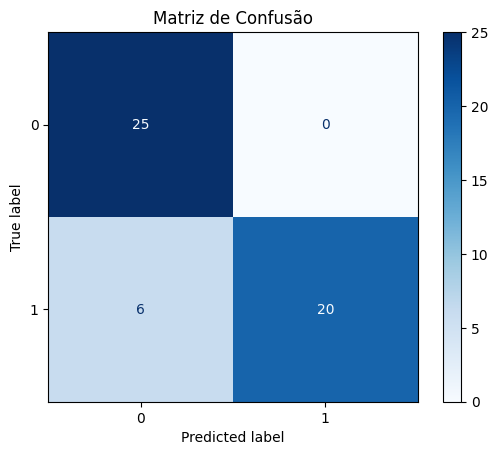


Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 0       0.81      1.00      0.89        25
    Classe 1       1.00      0.77      0.87        26

    accuracy                           0.88        51
   macro avg       0.90      0.88      0.88        51
weighted avg       0.91      0.88      0.88        51



In [ ]:
train_and_evaluate(L_audios, L_y, test_size=0.2)
